In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import os

C:\Users\rlack\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [5]:
from PIL import Image
import tensorflow as tf
from keras.preprocessing import image

In [35]:
import matplotlib.pyplot as plt

In [40]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 객체 탐지 (Object Detection)

In [42]:
import glob 

In [43]:
det_path = 'data/04_Foraminal_Stenosis_Data/'

case_list = sorted(os.listdir(det_path))
xml_list  = sorted(glob.glob(det_path + '*/*.xml')) 
png_list  = sorted(glob.glob(det_path + '*/*.png')) 

print('환자 폴더 수    :', len(case_list))
print('전체 이미지 수  :', len(png_list))
print('주석(XML) 수    :', len(xml_list))

환자 폴더 수    : 501
전체 이미지 수  : 6644
주석(XML) 수    : 1474


In [44]:
print(open(xml_list[0], encoding='utf-8').read())

<?xml version='1.0' encoding='utf-8'?>
<annotation>
  <folder>DatasetV0.28_ControlV2</folder>
  <filename>IM000002.png</filename>
  <path>Foramina_Detection\0001\IM000002.png</path>
  <source>
    <database>Unknown</database>
  </source>
  <size>
    <width>512</width>
    <height>512</height>
    <depth>1</depth>
  </size>
  <segmented>0</segmented>
  <object>
    <name>RFS0</name>
    <pose>Unspecified</pose>
    <truncated>0</truncated>
    <difficult>0</difficult>
    <bndbox>
      <xmin>234</xmin>
      <ymin>320</ymin>
      <xmax>274</xmax>
      <ymax>373</ymax>
    </bndbox>
    <level>L4-L5</level>
  </object>
</annotation>


In [45]:
import xml.etree.ElementTree as ET

In [46]:
def parse_voc_xml(xml_path):
    root = ET.parse(xml_path).getroot()

    case_id  = os.path.basename(os.path.dirname(xml_path))      
    slice_id = os.path.basename(xml_path).replace('.xml','')     
    png_path = xml_path.replace('.xml','.png')

    size  = root.find('size')
    img_w = int(size.find('width').text)
    img_h = int(size.find('height').text)

    if (img_w == 0 or img_h == 0) and os.path.exists(png_path):
        img_w, img_h = Image.open(png_path).size

    row_list = []
    for obj in root.findall('object'):
        name   = obj.find('name').text          
        bndbox = obj.find('bndbox')
        level  = obj.find('level')

        row_list.append({
            'case_id'  : case_id,
            'slice_id' : slice_id,
            'png_path' : png_path,
            'img_w'    : img_w,
            'img_h'    : img_h,
            'name'     : name,
            'side'     : name[0],                  
            'grade'    : int(name[-1]),            
            'level'    : level.text if level is not None else None,   
            'xmin'     : int(bndbox.find('xmin').text),
            'ymin'     : int(bndbox.find('ymin').text),
            'xmax'     : int(bndbox.find('xmax').text),
            'ymax'     : int(bndbox.find('ymax').text),
        })
    return row_list

In [47]:
box_list = []
for xml_path in xml_list:
    box_list = box_list + parse_voc_xml(xml_path)

df_box = pd.DataFrame(box_list)
print(df_box.shape)
df_box.head(5)

(2979, 13)


,case_id,slice_id,png_path,img_w,img_h,name,side,grade,level,xmin,ymin,xmax,ymax
0,0001,IM000002,data/04_Foraminal_Stenosis_Data\0001\IM000002.png,512,512,RFS0,R,0,L4-L5,234,320,274,373
1,0001,IM000003,data/04_Foraminal_Stenosis_Data\0001\IM000003.png,512,512,RFS0,R,0,L2-L3,247,203,279,259
2,0001,IM000003,data/04_Foraminal_Stenosis_Data\0001\IM000003.png,512,512,RFS2,R,2,L3-L4,242,263,274,318
3,0001,IM000003,data/04_Foraminal_Stenosis_Data\0001\IM000003.png,512,512,RFS3,R,3,L4-L5,236,322,274,373
4,0001,IM000003,data/04_Foraminal_Stenosis_Data\0001\IM000003.png,512,512,RFS0,R,0,L5-S1,239,377,285,423


In [48]:
print('주석이 있는 이미지 수 :', df_box.groupby(['case_id','slice_id']).ngroups)
print('주석이 있는 환자 수   :', df_box['case_id'].nunique())
print('전체 박스 수          :', len(df_box))
print(df_box['name'].value_counts())

주석이 있는 이미지 수 : 1474
주석이 있는 환자 수   : 469
전체 박스 수          : 2979
name
LFS0    1057
RFS0     952
LFS1     272
RFS1     236
LFS2     139
RFS2     115
LFS3     115
RFS3      93
Name: count, dtype: int64


In [49]:
print(pd.crosstab(df_box['side'], df_box['grade']))
print()
print(df_box['level'].value_counts())

grade     0    1    2    3
side                      
L      1057  272  139  115
R       952  236  115   93

level
L3-L4    795
L2-L3    686
L4-L5    649
L1-L2    571
L5-S1    278
Name: count, dtype: int64


In [50]:
box_per_image = df_box.groupby(['case_id','slice_id']).size()
print(box_per_image.describe())

count    1474.000000
mean        2.021031
std         1.037108
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
dtype: float64


**데이터 품질 점검**

In [51]:
cond_missing = ~df_box['png_path'].apply(os.path.exists)
print('이미지가 없는 박스 수 :', cond_missing.sum())
print(df_box.loc[cond_missing, ['case_id','slice_id']].drop_duplicates())

이미지가 없는 박스 수 : 1
     case_id  slice_id
1939    0329  IM000001


In [52]:
print(df_box[['img_w','img_h']].drop_duplicates().sort_values('img_w').to_string(index=False))

 img_w  img_h
   256    256
   320    320
   336    336
   352    352
   384    384
   432    432
   448    448
   480    480
   512    512
   560    560
   576    576
   672    672
   704    704
   720    720
   800    800
  1008   1008


In [53]:
df_box['box_w'] = df_box['xmax'] - df_box['xmin']
df_box['box_h'] = df_box['ymax'] - df_box['ymin']
df_box['area_ratio'] = (df_box['box_w'] * df_box['box_h']) / (df_box['img_w'] * df_box['img_h']) * 100

print(df_box[['box_w','box_h','area_ratio']].describe())

             box_w        box_h   area_ratio
count  2979.000000  2979.000000  2979.000000
mean     34.727090    44.159114     0.784008
std       9.772344    12.513292     0.141378
min      15.000000    20.000000     0.388755
25%      26.000000    33.000000     0.684366
50%      34.000000    43.000000     0.770950
75%      42.000000    52.000000     0.870117
max      64.000000    84.000000     1.371094


In [54]:
df_box = df_box.loc[df_box['png_path'].apply(os.path.exists)].reset_index(drop=True)
print(df_box.shape)

(2978, 16)


### 박스 시각화


In [55]:
import matplotlib.patches as patches

In [56]:
GRADE_COLOR = {0:'lime', 1:'yellow', 2:'orange', 3:'red'}

def draw_boxes(df_one, ax=None, show_level=True, title=None):
    png_path = df_one['png_path'].values[0]
    img = Image.open(png_path)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5,6.5))

    ax.imshow(img, cmap='gray')

    for _, row in df_one.iterrows():
        # patches.Rectangle( (좌상단 x, 좌상단 y), 가로, 세로 )
        rect = patches.Rectangle((row['xmin'], row['ymin']),
                                 row['xmax'] - row['xmin'],
                                 row['ymax'] - row['ymin'],
                                 linewidth=1.6,
                                 edgecolor=GRADE_COLOR[row['grade']],
                                 facecolor='none')
        ax.add_patch(rect)

        text = row['name']
        if show_level:
            text = text + ' / ' + str(row['level'])
        ax.text(row['xmin'], row['ymin'] - 5, text,
                color=GRADE_COLOR[row['grade']], fontsize=8.5)

    if title is None:
        title = df_one['case_id'].values[0] + ' / ' + df_one['slice_id'].values[0]
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    return ax

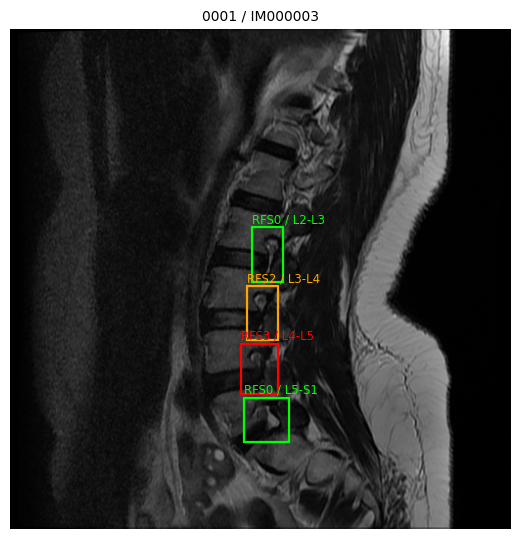

In [57]:
cond1 = (df_box['case_id']=='0001') & (df_box['slice_id']=='IM000003')
draw_boxes(df_box.loc[cond1])
plt.show()

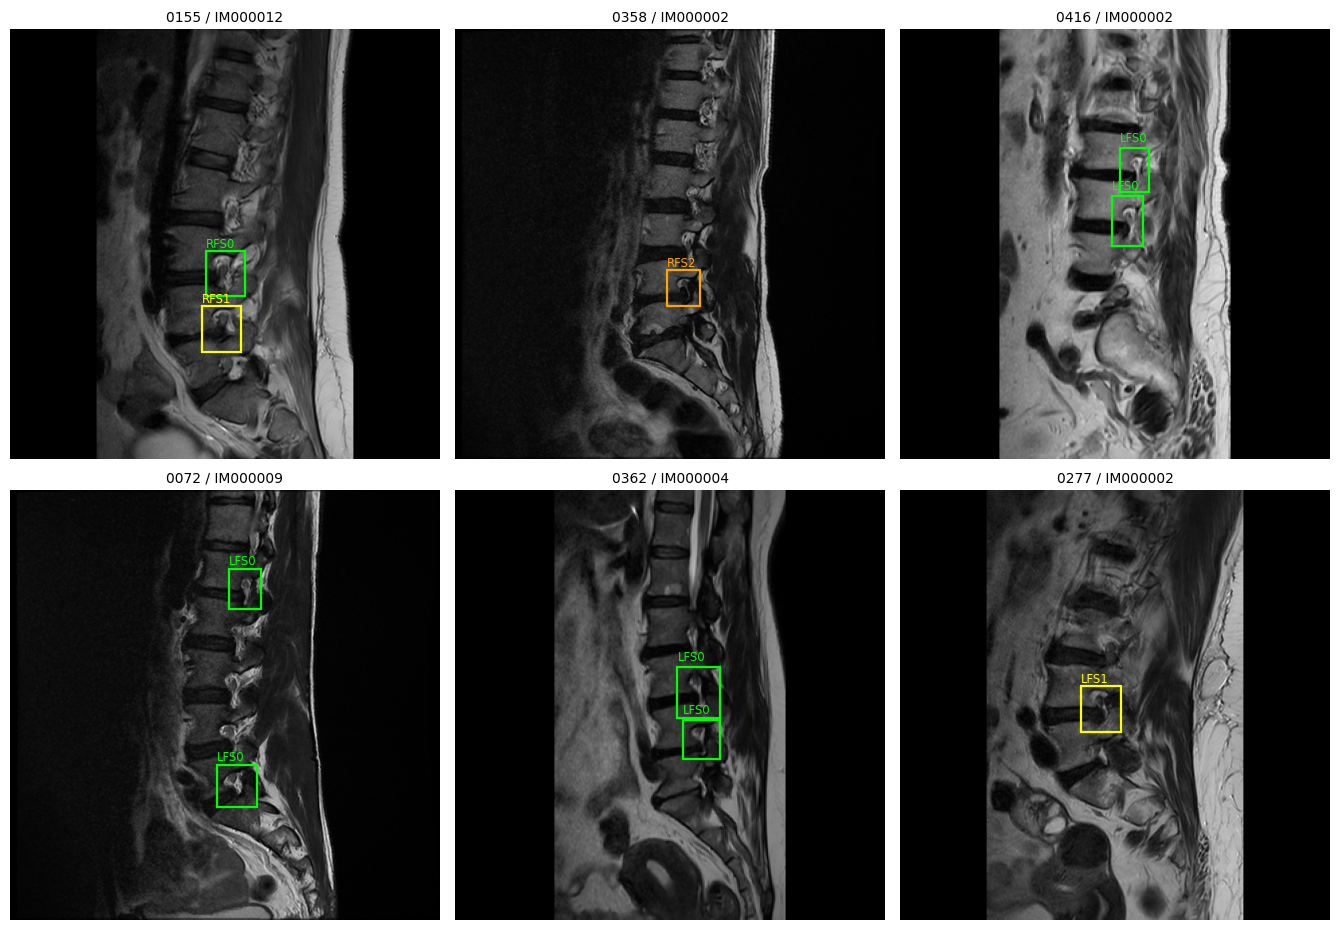

In [58]:
sample_keys = df_box[['case_id','slice_id']].drop_duplicates().sample(6, random_state=1234)

fig, axes = plt.subplots(2, 3, figsize=(13.5,9.5))
for ax, (_, key) in zip(axes.flatten(), sample_keys.iterrows()):
    cond1 = (df_box['case_id']==key['case_id']) & (df_box['slice_id']==key['slice_id'])
    draw_boxes(df_box.loc[cond1], ax=ax, show_level=False)
plt.tight_layout()
plt.show()

### IoU 직접 구현


In [59]:
def compute_iou(box1, box2):
    inter_xmin = max(box1[0], box2[0])
    inter_ymin = max(box1[1], box2[1])
    inter_xmax = min(box1[2], box2[2])
    inter_ymax = min(box1[3], box2[3])

    inter_w = max(0.0, inter_xmax - inter_xmin)
    inter_h = max(0.0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union_area = area1 + area2 - inter_area     

    if union_area == 0:
        return 0.0
    return inter_area / union_area

In [60]:
print('완전히 동일한 박스 :', compute_iou([0,0,10,10], [0,0,10,10]))          # 1.0
print('전혀 겹치지 않음   :', compute_iou([0,0,10,10], [20,20,30,30]))        # 0.0
print('절반만 겹침        :', round(compute_iou([0,0,10,10], [5,0,15,10]), 4)) # 5*10 / (100+100-50) = 0.3333
print('한쪽이 다른쪽 포함 :', round(compute_iou([0,0,10,10], [0,0,5,5]), 4))   # 25 / 100 = 0.25

완전히 동일한 박스 : 1.0
전혀 겹치지 않음   : 0.0
절반만 겹침        : 0.3333
한쪽이 다른쪽 포함 : 0.25


In [61]:
cond1 = (df_box['case_id']=='0001') & (df_box['slice_id']=='IM000003')
df_demo = df_box.loc[cond1].reset_index(drop=True)

img_demo = np.array(Image.open(df_demo['png_path'].values[0]))
boxes_demo = df_demo[['xmin','ymin','xmax','ymax']].values.astype('float32')
names_demo = df_demo['name'].values

print(img_demo.shape)
print(boxes_demo)

(512, 512)
[[247. 203. 279. 259.]
 [242. 263. 274. 318.]
 [236. 322. 274. 373.]
 [239. 377. 285. 423.]]


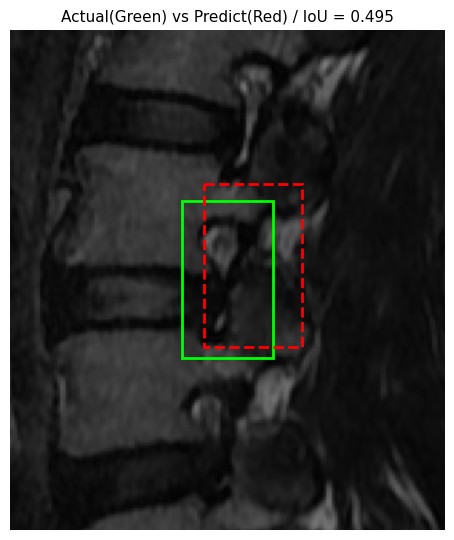

In [62]:
gt_box   = boxes_demo[1]
pred_box = gt_box + np.array([8, -6, 10, -4])   

fig, ax = plt.subplots(figsize=(6.5,6.5))
ax.imshow(img_demo, cmap='gray')
ax.add_patch(patches.Rectangle((gt_box[0],gt_box[1]), gt_box[2]-gt_box[0], gt_box[3]-gt_box[1],
                               linewidth=2, edgecolor='lime', facecolor='none'))
ax.add_patch(patches.Rectangle((pred_box[0],pred_box[1]), pred_box[2]-pred_box[0], pred_box[3]-pred_box[1],
                               linewidth=2, edgecolor='red', facecolor='none', linestyle='--'))
ax.set_title('Actual(Green) vs Predict(Red) / IoU = ' + str(round(compute_iou(gt_box, pred_box),3)), fontsize=11)
ax.axis('off')

# 확대해서 보기
ax.set_xlim(gt_box[0]-60, gt_box[2]+60)
ax.set_ylim(gt_box[3]+60, gt_box[1]-60)
plt.show()

### NMS 직접 구현


In [63]:
def non_max_suppression(boxes, scores, iou_threshold=0.5):
    index_list = np.argsort(scores)[::-1]
    keep_list = []

    while len(index_list) > 0:
        current = index_list[0]       
        keep_list.append(current)

        rest = index_list[1:]
        if len(rest) == 0:
            break

        iou_list = np.array([compute_iou(boxes[current], boxes[j]) for j in rest])

        index_list = rest[iou_list < iou_threshold]

    return keep_list

In [64]:
np.random.seed(1234)

pred_boxes = []
pred_scores = []
for box in boxes_demo:
    for k in range(4):                               
        noise = np.random.randint(-10, 10, size=4)
        pred_boxes.append(box + noise)
        pred_scores.append(np.random.uniform(0.4, 0.99))

pred_boxes  = np.array(pred_boxes, dtype='float32')
pred_scores = np.array(pred_scores)
print('NMS 이전 박스 수 :', len(pred_boxes))

keep = non_max_suppression(pred_boxes, pred_scores, iou_threshold=0.4)
print('NMS 이후 박스 수 :', len(keep))

NMS 이전 박스 수 : 16
NMS 이후 박스 수 : 5


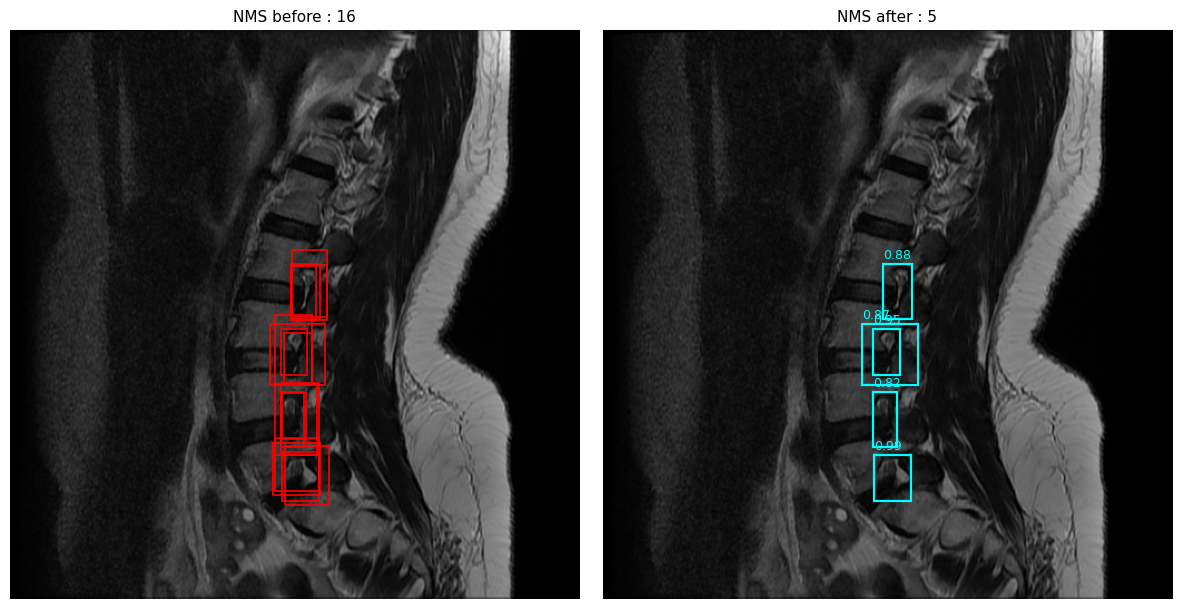

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].imshow(img_demo, cmap='gray')
for box, score in zip(pred_boxes, pred_scores):
    axes[0].add_patch(patches.Rectangle((box[0],box[1]), box[2]-box[0], box[3]-box[1],
                                        linewidth=1.2, edgecolor='red', facecolor='none'))
axes[0].set_title('NMS before : ' + str(len(pred_boxes)) , fontsize=11)
axes[0].axis('off')

axes[1].imshow(img_demo, cmap='gray')
for i in keep:
    box = pred_boxes[i]
    axes[1].add_patch(patches.Rectangle((box[0],box[1]), box[2]-box[0], box[3]-box[1],
                                        linewidth=1.6, edgecolor='cyan', facecolor='none'))
    axes[1].text(box[0], box[1]-5, str(round(pred_scores[i],2)), color='cyan', fontsize=9)
axes[1].set_title('NMS after : ' + str(len(keep)) , fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Pascal VOC -> YOLO 형식 변환


In [66]:
CLASS_MODE = 'single'      # 'single' / 'side' / 'grade' / 'full' 중 선택

CLASS_MAP = {
    'single' : (['foramen'],
                lambda row: 0),
    'side'   : (['L','R'],
                lambda row: 0 if row['side']=='L' else 1),
    'grade'  : (['FS0','FS1','FS2','FS3'],
                lambda row: row['grade']),
    'full'   : (['LFS0','LFS1','LFS2','LFS3','RFS0','RFS1','RFS2','RFS3'],
                lambda row: (0 if row['side']=='L' else 4) + row['grade']),
}

class_names, class_func = CLASS_MAP[CLASS_MODE]
print(CLASS_MODE, '/ 클래스 수 :', len(class_names), '/', class_names)

single / 클래스 수 : 1 / ['foramen']


In [67]:
def voc_to_yolo(row):
    cx = ((row['xmin'] + row['xmax']) / 2) / row['img_w']
    cy = ((row['ymin'] + row['ymax']) / 2) / row['img_h']
    w  = (row['xmax'] - row['xmin']) / row['img_w']
    h  = (row['ymax'] - row['ymin']) / row['img_h']
    return class_func(row), cx, cy, w, h

df_box[['cls','cx','cy','w','h']] = df_box.apply(voc_to_yolo, axis=1, result_type='expand')
df_box[['name','img_w','xmin','ymin','xmax','ymax','cls','cx','cy','w','h']].head(5)

,name,img_w,xmin,ymin,xmax,ymax,cls,cx,cy,w,h
0,RFS0,512,234,320,274,373,0.0,0.496094,0.676758,0.078125,0.103516
1,RFS0,512,247,203,279,259,0.0,0.513672,0.451172,0.062500,0.109375
2,RFS2,512,242,263,274,318,0.0,0.503906,0.567383,0.062500,0.107422
3,RFS3,512,236,322,274,373,0.0,0.498047,0.678711,0.074219,0.099609
4,RFS0,512,239,377,285,423,0.0,0.511719,0.781250,0.089844,0.089844


In [68]:
print(df_box[['cx','cy','w','h']].describe().loc[['min','max']])

cond_bad = (df_box[['cx','cy','w','h']] < 0).any(axis=1) | (df_box[['cx','cy','w','h']] > 1).any(axis=1)
print()
print('범위를 벗어난 박스 수 :', cond_bad.sum())

           cx        cy         w         h
min  0.412500  0.095486  0.049603  0.062500
max  0.663086  0.820312  0.115625  0.142361

범위를 벗어난 박스 수 : 0


In [69]:
from sklearn.model_selection import train_test_split

In [70]:
case_ids = sorted(df_box['case_id'].unique())
train_cases, val_cases = train_test_split(case_ids, test_size=0.2, random_state=1234)

print('학습 환자 수 :', len(train_cases), '/ 검증 환자 수 :', len(val_cases))

print('겹치는 환자 :', len(set(train_cases) & set(val_cases)))

학습 환자 수 : 374 / 검증 환자 수 : 94
겹치는 환자 : 0


In [71]:
import shutil

In [72]:
CLASS_MODE

'single'

In [73]:
yolo_root = 'data/04_Foraminal_Stenosis_Data/yolo_foramina_' + CLASS_MODE

def build_yolo_dataset(df_source, case_group, split_name):
    img_dir = os.path.join(yolo_root, 'images', split_name)
    lbl_dir = os.path.join(yolo_root, 'labels', split_name)
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    cond = df_source['case_id'].isin(case_group)
    df_split = df_source.loc[cond]

    n_image = 0
    for (case_id, slice_id), df_one in df_split.groupby(['case_id','slice_id']):
        file_stem = case_id + '_' + slice_id       # 예) 0001_IM000003

        shutil.copy2(df_one['png_path'].values[0], os.path.join(img_dir, file_stem + '.png'))

        with open(os.path.join(lbl_dir, file_stem + '.txt'), 'w', encoding='utf-8') as f:
            for _, row in df_one.iterrows():
                print('%d %.6f %.6f %.6f %.6f' % (row['cls'], row['cx'], row['cy'], row['w'], row['h']), file=f)

        n_image = n_image + 1

    print(split_name, ':', n_image, '장 /', len(df_split), '개 박스')

In [74]:
build_yolo_dataset(df_box, train_cases, 'train')
build_yolo_dataset(df_box, val_cases,   'val')

train : 1166 장 / 2356 개 박스
val : 307 장 / 622 개 박스


In [75]:
print('train 이미지 :', len(glob.glob(yolo_root + '/images/train/*.png')))
print('train 라벨   :', len(glob.glob(yolo_root + '/labels/train/*.txt')))
print('val   이미지 :', len(glob.glob(yolo_root + '/images/val/*.png')))
print('val   라벨   :', len(glob.glob(yolo_root + '/labels/val/*.txt')))

train 이미지 : 1220
train 라벨   : 1220
val   이미지 : 307
val   라벨   : 307


In [76]:
sample_label = sorted(glob.glob(yolo_root + '/labels/train/*.txt'))[0]
print(sample_label)
print(open(sample_label, encoding='utf-8').read())

data/04_Foraminal_Stenosis_Data/yolo_foramina_single/labels/train\0003_IM000000.txt
0 0.558594 0.579102 0.082031 0.099609



In [77]:
yaml_line_list = [
    'path: '  + os.path.abspath(yolo_root).replace(os.sep, '/'),
    'train: images/train',
    'val: images/val',
    'nc: '    + str(len(class_names)),
    'names: ' + str(class_names),
]

yaml_path = os.path.join(yolo_root, 'data.yaml')
with open(yaml_path, 'w', encoding='utf-8') as f:
    for line in yaml_line_list:
        print(line, file=f)

print(open(yaml_path, encoding='utf-8').read())

path: C:/Users/rlack/OneDrive/바탕 화면/오즈코딩스쿨_AI헬스케어부트캠프_260901/수업 준비 자료/data/04_Foraminal_Stenosis_Data/yolo_foramina_single
train: images/train
val: images/val
nc: 1
names: ['foramen']



### 변환 결과 역검증

In [78]:
def read_yolo_label(txt_path, img_w, img_h):
    box_list = []

    for line in open(txt_path, encoding='utf-8'):
        line = line.strip()
        if line == '':
            continue
        cls, cx, cy, w, h = line.split()
        cx = float(cx) * img_w
        cy = float(cy) * img_h
        w  = float(w)  * img_w
        h  = float(h)  * img_h
        box_list.append([int(cls), cx - w/2, cy - h/2, cx + w/2, cy + h/2])
    return box_list

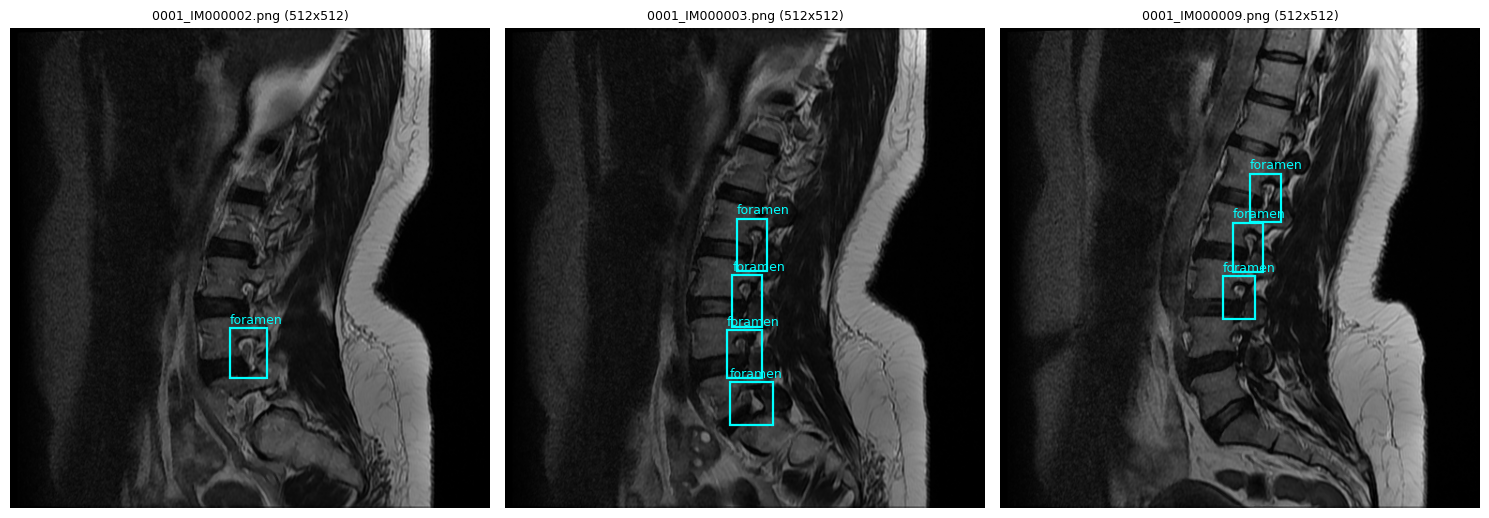

In [79]:
sample_images = sorted(glob.glob(yolo_root + '/images/val/*.png'))[:3]

fig, axes = plt.subplots(1, 3, figsize=(15,5.5))
for ax, img_file in zip(axes, sample_images):
    img = Image.open(img_file)
    img_w, img_h = img.size

    txt_file = os.path.join(yolo_root, 'labels', 'val',
                            os.path.basename(img_file).replace('.png','.txt'))
    box_list = read_yolo_label(txt_file, img_w, img_h)

    ax.imshow(img, cmap='gray')
    for cls, xmin, ymin, xmax, ymax in box_list:
        ax.add_patch(patches.Rectangle((xmin,ymin), xmax-xmin, ymax-ymin,
                                       linewidth=1.6, edgecolor='cyan', facecolor='none'))
        ax.text(xmin, ymin-5, class_names[cls], color='cyan', fontsize=9)
    ax.set_title(os.path.basename(img_file) + ' (' + str(img_w) + 'x' + str(img_h) + ')', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

### YOLO 모형 학습


In [80]:
# %pip install ultralytics

In [81]:
from ultralytics import YOLO

In [82]:
try:
    model_yolo = YOLO('yolov8n.pt')        
    result = model_yolo.train(data=os.path.abspath(yaml_path),
                              epochs=5,
                              imgsz=512,
                              batch=8,
                              workers=0,      
                              project='data/04_Foraminal_Stenosis_Data/yolo_runs',
                              name=CLASS_MODE)
except Exception as e:
    print(e)

New https://pypi.org/project/ultralytics/8.4.144 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.138  Python-3.13.5 torch-2.12.1+cpu CPU (12th Gen Intel Core i7-12700F)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\rlack\OneDrive\ \_AI_260901\  \data\04_Foraminal_Stenosis_Data\yolo_foramina_single\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=N

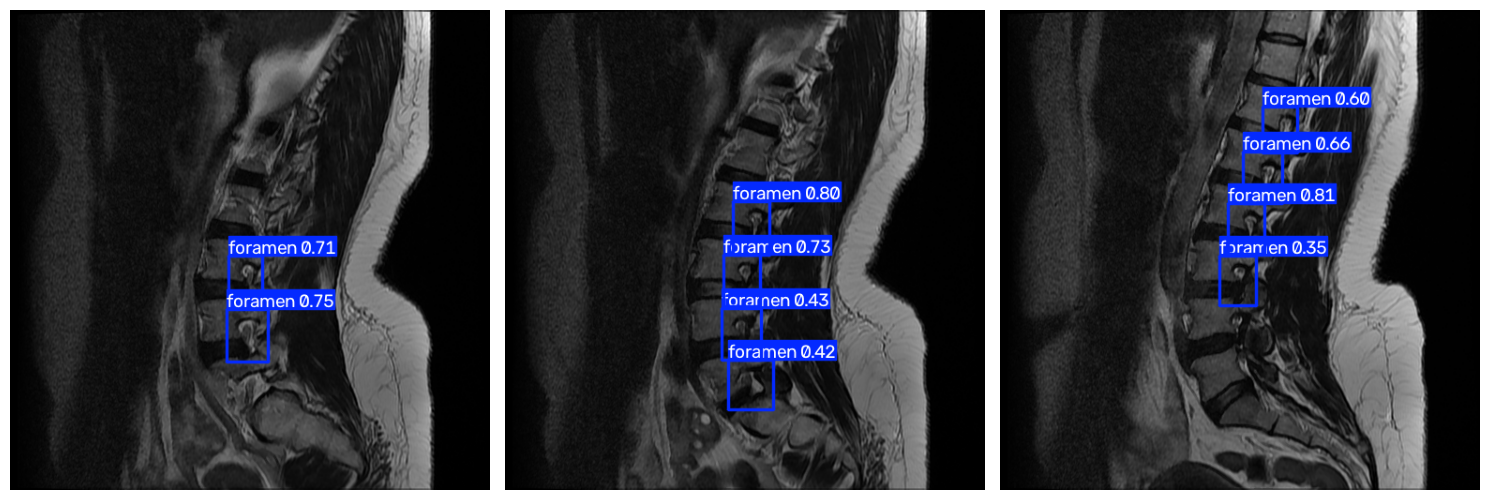

In [83]:
try:
    pred_list = model_yolo.predict(sample_images, imgsz=512, conf=0.25, verbose=False)

    fig, axes = plt.subplots(1, len(pred_list), figsize=(5*len(pred_list), 5.5))
    for ax, pred in zip(np.atleast_1d(axes), pred_list):
        ax.imshow(pred.plot()[:,:,::-1])      
        ax.axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(e)

In [84]:
try:
    metrics = model_yolo.val(data=os.path.abspath(yaml_path),
                             imgsz=512,
                             split='val',
                             workers=0,
                             project='data/04_Foraminal_Stenosis_Data/yolo_runs',
                             name=CLASS_MODE + '_val')
except Exception as e:
    print(e)

Ultralytics 8.4.138  Python-3.13.5 torch-2.12.1+cpu CPU (12th Gen Intel Core i7-12700F)
val: Fast image access  (ping: 0.10.0 ms, read: 522.9285.1 MB/s, size: 82.0 KB)
val: Scanning C:\Users\rlack\OneDrive\바탕 화면\오즈코딩스쿨_AI헬스케어부트캠프_260901\수업 준비 자료\data\04_Foraminal_Stenosis_Data\yolo_foramina_single\labels\val.cache... 307 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 307/307 214.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.1it/s 9.3s0.5s
                   all        307        622      0.783      0.873      0.899      0.561
Speed: 0.4ms preprocess, 24.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Users\rlack\OneDrive\ \_AI_260901\  \runs\detect\data\04_Foraminal_Stenosis_Data\yolo_runs\single_val


In [85]:
try:
    print('Precision (P) :', round(metrics.box.mp, 4))
    print('Recall    (R) :', round(metrics.box.mr, 4))
    print('mAP50         :', round(metrics.box.map50, 4))
    print('mAP75         :', round(metrics.box.map75, 4))
    print('mAP50-95      :', round(metrics.box.map, 4))

    print()
    for i in range(len(class_names)):
        print('클래스', class_names[i], ': AP50-95 =', round(float(metrics.box.maps[i]), 4))
except Exception as e:
    print(e)

Precision (P) : 0.783
Recall    (R) : 0.873
mAP50         : 0.8989
mAP75         : 0.6666
mAP50-95      : 0.5607

클래스 foramen : AP50-95 = 0.5607


In [86]:
try:
    iou_thr = np.arange(0.5, 1.0, 0.05).round(2)
    ap_mean = metrics.box.all_ap.mean(axis=0)     

    df_ap = pd.DataFrame({'iou_threshold' : iou_thr,
                          'AP'            : ap_mean.round(4)})

    fig = px.line(df_ap, x='iou_threshold', y='AP', markers=True,
                  title='IoU 임계값에 따른 AP 변화 (' + CLASS_MODE + ')')
    fig.add_hline(y=float(metrics.box.map), line_dash='dash', line_color='red',
                  annotation_text='mAP50-95 = ' + str(round(float(metrics.box.map), 4)))
    fig.update_layout(width=760, height=430, yaxis_range=[0, 1])
    fig.show()

    print(df_ap.to_string(index=False))
except Exception as e:
    print(e)

 iou_threshold     AP
          0.50 0.8989
          0.55 0.8978
          0.60 0.8932
          0.65 0.8752
          0.70 0.8024
          0.75 0.6666
          0.80 0.4142
          0.85 0.1409
          0.90 0.0174
          0.95 0.0000


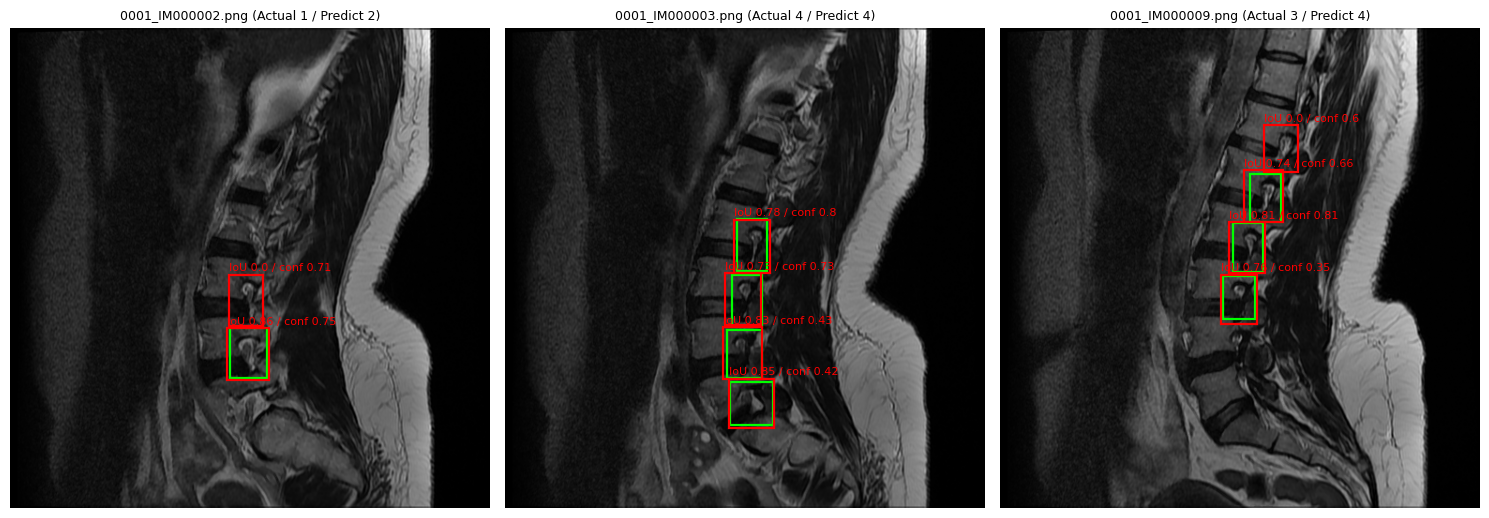

In [88]:
try:
    pred_list = model_yolo.predict(sample_images, imgsz=512, conf=0.25, verbose=False)

    fig, axes = plt.subplots(1, len(sample_images), figsize=(5*len(sample_images), 5.5))
    for ax, img_file, pred in zip(np.atleast_1d(axes), sample_images, pred_list):
        img = Image.open(img_file)
        img_w, img_h = img.size
        ax.imshow(img, cmap='gray')

        txt_file = os.path.join(yolo_root, 'labels', 'val',
                                os.path.basename(img_file).replace('.png', '.txt'))
        gt_list = read_yolo_label(txt_file, img_w, img_h)
        for cls, xmin, ymin, xmax, ymax in gt_list:
            ax.add_patch(patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                           linewidth=1.6, edgecolor='lime', facecolor='none'))

        pred_box_list  = pred.boxes.xyxy.cpu().numpy()
        pred_conf_list = pred.boxes.conf.cpu().numpy()

        for box, conf in zip(pred_box_list, pred_conf_list):
            ax.add_patch(patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                           linewidth=1.6, edgecolor='red', facecolor='none'))

            iou_list = [compute_iou(box, gt[1:]) for gt in gt_list]
            best_iou = max(iou_list) if len(iou_list) > 0 else 0.0
            ax.text(box[0], box[1]-4,
                    'IoU ' + str(round(best_iou, 2)) + ' / conf ' + str(round(float(conf), 2)),
                    color='red', fontsize=8)

        ax.set_title(os.path.basename(img_file) +
                     ' (Actual ' + str(len(gt_list)) + ' / Predict ' + str(len(pred_box_list)) + ')',
                     fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(e)